In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report , f1_score

In [30]:
#from google.colab import drive
#drive.mount("/content/drive")

In [31]:
df = pd.read_csv("/content/drive/MyDrive/diabetes_diabet.csv")

zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)
df[zero_as_missing] = df[zero_as_missing].fillna(df[zero_as_missing].median())

print(df.shape)
print(df["Outcome"].value_counts())
df.head()

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [32]:
X = df.drop(columns=["Outcome"]).values
y = df["Outcome"].values

pca = PCA(n_components=4)
pca.fit(X)
X = pca.transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("train:", X_train.shape, " test:", X_test.shape)

train: (614, 4)  test: (154, 4)


In [49]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=30 , factor=0.6 , min_lr=0.001)
callback = [early , reduce]

models = {
    "Model_Costum" : model
}

histories = {}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    histories[name] = model.fit(
        X_train , y_train,
        validation_data=(X_test, y_test),
        epochs=200,
        callbacks=early, verbose=1)


=== Training Model_Costum ===
Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7671 - loss: 0.4971 - val_accuracy: 0.7013 - val_loss: 0.5478
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7785 - loss: 0.4828 - val_accuracy: 0.6948 - val_loss: 0.5450
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7687 - loss: 0.4922 - val_accuracy: 0.7013 - val_loss: 0.5437
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7573 - loss: 0.4943 - val_accuracy: 0.7078 - val_loss: 0.5462
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7736 - loss: 0.4868 - val_accuracy: 0.7078 - val_loss: 0.5475
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7736 - loss: 0.4937 - val_accuracy: 0.7078 - val_loss: 0.5471
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7736 - loss: 0.4855 - val_accuracy: 0.7013 - val_loss: 0.5457
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7752 - los

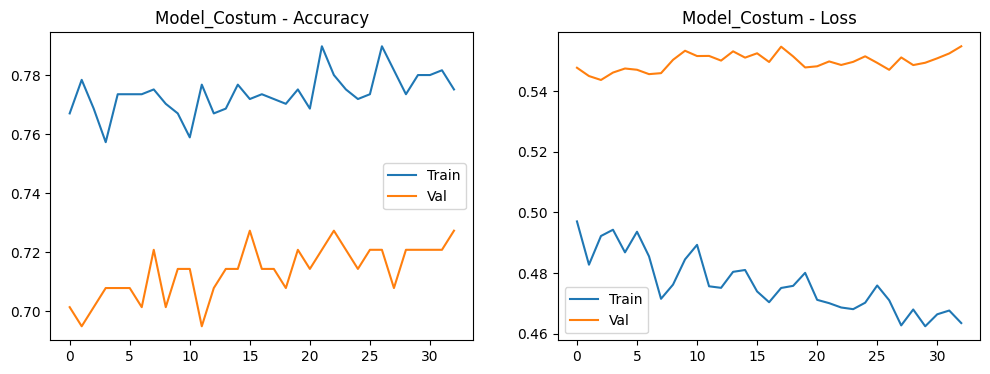

<Figure size 640x480 with 0 Axes>

In [47]:
for name, his in histories.items():
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(his.history["accuracy"])
    plt.plot(his.history["val_accuracy"])
    plt.title(f"{name} - Accuracy")
    plt.legend(["Train", "Val"])

    plt.subplot(1, 2, 2)
    plt.plot(his.history["loss"])
    plt.plot(his.history["val_loss"])
    plt.title(f"{name} - Loss")
    plt.legend(["Train", "Val"])
    plt.show()
    plt.savefig("model_performance.png")

In [48]:
test_ds = (X_test , y_test)
class_names = ["No Diabetes", "Diabetes"]
y_true = y_test

for name, model in models.items():
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true , y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}  F1: {f1:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}")
    print("Confusion Matrix:\n", cm)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

=== Model_Costum ===
Accuracy: 0.7013  F1: 0.5400  Precision: 0.6928  Recall: 0.7013
Confusion Matrix:
 [[81 19]
 [27 27]]
              precision    recall  f1-score   support

 No Diabetes       0.75      0.81      0.78       100
    Diabetes       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [50]:
import pickle
with open("PCA.pkl", "wb") as f:
    pickle.dump(pca, f)
model.save("model_diabet.keras")